## Notebook to learn to play with tif images

In [1]:
import sys
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt

import experiment_settings
import build_model
import train_model
import build_data
import methods

import tensorflow as tf

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")  

# tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
print(tf.config.list_physical_devices('GPU'))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GET SETTINGS
EXP_NAME = "exp0"
settings = experiment_settings.get_settings(EXP_NAME)

# SET RANDOM SEEDS
np.random.seed(settings["rng_seed"])
random.seed(settings["rng_seed"])
tf.random.set_seed(settings["rng_seed"])

In [4]:
# LOAD THE DATA
imp.reload(build_data)
imp.reload(methods)

tags_train, tags_val, denseweight_dist = build_data.make_sample_list(settings)

tfds_train = build_data.build_tf_dataset(settings, tags_train, settings["batch_size"])
tfds_val = build_data.build_tf_dataset(settings, tags_val, settings["batch_size"])

batch_shape = np.shape(next(tfds_val.as_numpy_iterator())[0])
print(f"{batch_shape = }")

output region shape = (327, 327)
ntrain = 6400, nval = 1600
Metal device set to: Apple M1 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB

6400
1600
batch_shape = (32, 114, 114, 6)


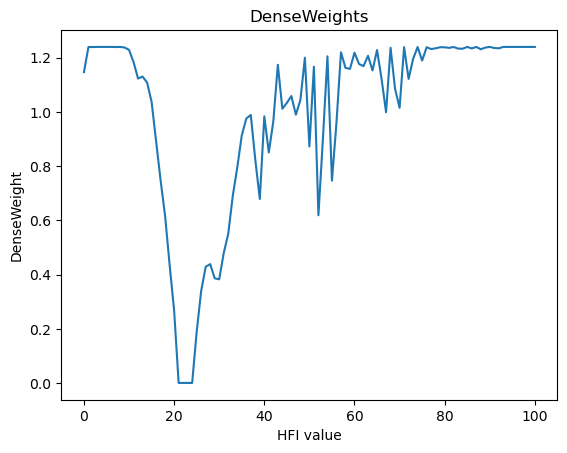

In [5]:
plt.title('DenseWeights')
plt.plot(np.arange(0,101,1), denseweight_dist)
plt.xlabel('HFI value')
plt.ylabel("DenseWeight")
plt.show()

In [6]:
# TRAIN THE MODEL
imp.reload(build_model)
imp.reload(train_model)
imp.reload(methods)

tf.keras.backend.clear_session()
model = build_model.build_model(settings, input_shape=batch_shape[1:])

model, fit_summary, history, settings = train_model.train_model(settings, model, tfds_train, tfds_val, denseweight_dist)
fit_summary

Epoch 1/1000
200/200 [==============================] - 44s 217ms/step - loss: 18.7326 - mae: 17.0529 - val_loss: 13.3834 - val_mae: 13.2340 - lr: 0.0010
Epoch 2/1000
200/200 [==============================] - 43s 214ms/step - loss: 13.6895 - mae: 12.3181 - val_loss: 11.7073 - val_mae: 10.3988 - lr: 0.0010
Epoch 3/1000
200/200 [==============================] - 43s 216ms/step - loss: 13.0068 - mae: 11.6816 - val_loss: 12.1822 - val_mae: 11.0080 - lr: 0.0010
Epoch 4/1000
200/200 [==============================] - 43s 215ms/step - loss: 12.4358 - mae: 11.0878 - val_loss: 13.3061 - val_mae: 13.5177 - lr: 0.0010
Epoch 5/1000
200/200 [==============================] - 44s 218ms/step - loss: 12.0551 - mae: 10.8337 - val_loss: 11.9436 - val_mae: 11.0776 - lr: 0.0010
Epoch 5: early stopping


{'elapsed_time': 216.9602551460266,
 'best_epoch': 1,
 'loss_train': 13.689492225646973,
 'loss_valid': 11.707334518432617,
 'mae_train': 12.318058967590332,
 'mae_valid': 10.398794174194336}

In [7]:
print("training complete.")

training complete.
